### ambiente anaconda linux YouTube

conda activate YouTub

conda env list

3 classes

# Projeto 6: Classificação multiclasse iris

## Etapa 1: Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
# dividimos as base de dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch import nn, optim
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
torch.__version__

'2.8.0+cu128'

In [2]:
# na semente para na repetição dos experimentos teremos o mesmo valor ou os resultados 

np.random.seed(123)
torch.manual_seed(123)

## Etapa 2: Base de dados

In [3]:
# carrendo a base de dados
base = pd.read_csv('iris.csv')


### Três tipos de plantas Iris

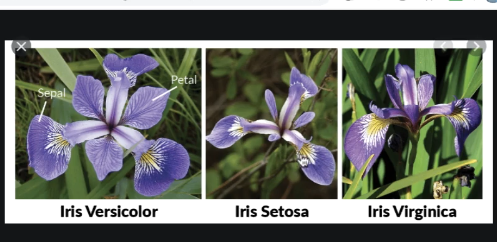


In [4]:
base.tail(5)

,sepal length,sepal width,petal length,petal width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
# tamanho da sepal e da petal para saber o tipo da planta

In [6]:
base.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
base['class'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

<Axes: xlabel='count', ylabel='class'>

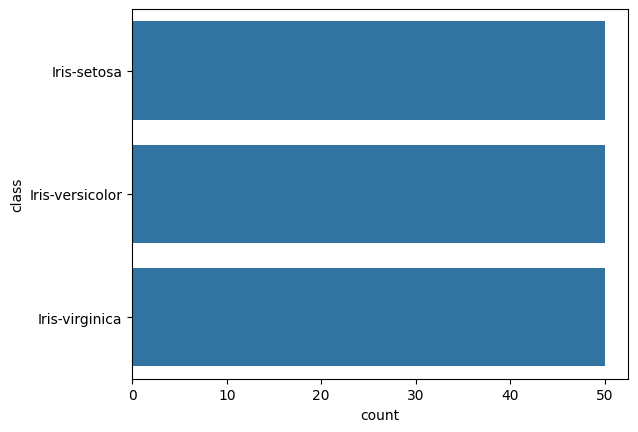

In [8]:
sns.countplot(base['class'])

In [9]:
len(base)

150

Rectangle(xy=(-0.4, 0), width=0.8, height=50, angle=0)
Rectangle(xy=(0.6, 0), width=0.8, height=50, angle=0)
Rectangle(xy=(1.6, 0), width=0.8, height=50, angle=0)


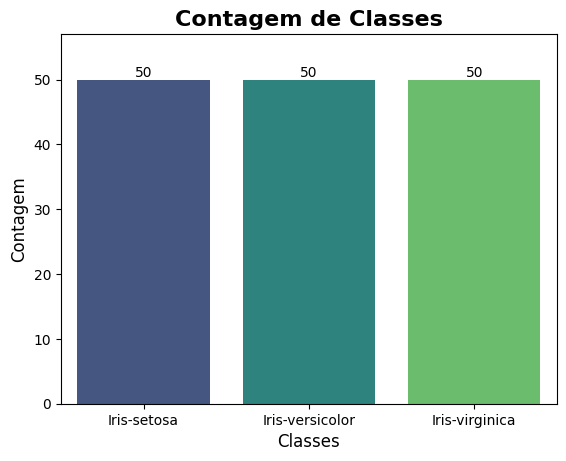

In [10]:
import matplotlib.pyplot as plt

# Cria o countplot com uma paleta de cores
ax = sns.countplot(x='class', data=base, palette='viridis', hue='class', legend=False)

# Adiciona um título ao gráfico
plt.title('Contagem de Classes', fontsize=16, fontweight='bold')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Contagem', fontsize=12)

# Obtém a contagem máxima para definir o novo limite do eixo Y
max_count = base['class'].value_counts().max()

# Define o limite do eixo Y. Adiciona um extra para deixar espaço no topo.
plt.ylim(0, max_count + 7) # Aumenta a altura para o dobro da contagem máxima


# Adiciona os valores em cima de cada barra
for p in ax.patches:
    print(p)
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

temos dados bem balanceados e nos vamos precisar fazer a divisão: Uma variável para armazenar os previsores e outra a classe.

In [11]:
print('lista previsores: ',list(base.columns[0:4]))
print('lista classes: ',list(base.columns[3:4]))

lista previsores:  ['sepal length', 'sepal width', 'petal length', 'petal width']
lista classes:  ['petal width']


In [12]:
previsores = base.iloc[:, 0:4].values
classe = base.iloc[:, 4].values

In [13]:
previsores.shape # linha e colunas

(150, 4)

In [14]:
classe.shape

(150,)

In [15]:
np.unique(base['class']) 

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [16]:
# converteremos strings para númericos

In [17]:
# o sklearn alguns convertem direta
# para o pytorch tem que fazer o processo.

encoder = LabelEncoder()
# adequar os dados e fazer a transformação
classe = encoder.fit_transform(classe)

In [18]:
np.unique(classe)

array([0, 1, 2])

In [19]:
# 'Iris-setosa'=>0, 'Iris-versicolor'=>1, 'Iris-virginica'=>2

In [20]:
# divisão para treinamento e teste
#25% para teste e 75% para o treino

previsores_treinamento, previsores_teste, classe_treinamento, classe_teste = train_test_split(previsores,
                                                                                              classe,
                                                                                              test_size=0.25)

In [21]:
previsores_treinamento.shape # 4 caractéristicas de previsão para a planta

(112, 4)

classe_treinamento.shape #1 classificação

In [23]:
previsores_teste.shape

(38, 4)

In [24]:
classe_teste.shape

(38,)

In [25]:
# tipo numpy os dados, quando usa o values

type(previsores_treinamento)

numpy.ndarray

In [26]:
# passsando para o formato tensor para o torch
# float 0,3 exemplo, e long é número inteiro 2
previsores_treinamento = torch.tensor(previsores_treinamento, dtype = torch.float)
classe_treinamento = torch.tensor(classe_treinamento, dtype=torch.long)

In [27]:
type(previsores_treinamento)

torch.Tensor

In [28]:
type(classe_treinamento)

torch.Tensor

## Etapa 3: Construção do modelo

In [29]:
base.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width', 'class'], dtype='object')

4 atributos na entrada (4 neurônios na entrada), para previsão, as colunas: 'sepal length', 'sepal width', 'petal length' e 'petal width', 


4 neurônios na camada oculta mais 4 neurônios na segunda camada oculta. 

E por fim 3 neurônios na camada de saída, nos 3 tipos de plantas da coluna 'class'

In [30]:
# 4 -> 4 -> 4 -> 3
#input , hidden layer, hidden layer, output
# (entradas + saídas) / 2 = (4 + 3) / 2

In [31]:
(4 + 3) / 2

3.5

In [33]:
round(((4 + 3) / 2),0)

4.0

Como não estamos usando validação cruzada e também não estamos trabalhando com o tunning de parâmetros, então não vamos usar no formato de classe. 

Então faremos a condifiação de uma maneira mais simples. Fazendo uma definição do próprio classificador. 

In [36]:
# sequência das camadas
classificador = nn.Sequential(
    nn.Linear(4, 4), # densa, camada linear
    nn.ReLU(), # função de ativação
    nn.Linear(4, 4), # próxima camada com 4 neurônios, tanto na primeira camada de oculta como na segunda camada oculta. 
    nn.ReLU(), # função ativação
    nn.Linear(4, 3) # última camada, 4 neurônios na camada oculta, e 3 neurônios na camada de saída
)


- classificação com mais classificações (mais de 1 classe) a função de ativação será pelo softmax que, faz uma probabilidade para cada uma das classes; 

- diferente quando temos um só classe de saída de classificação que colocamos uma função de ativação no final depois do nn.Linear(X,Out).

Antes para a validação era usada o Binary cross-entropy (BCE).

Binary cross-entropy (BCE), also known as log loss, is a loss function in machine learning for binary classification problems that quantifies the difference between the actual binary labels (0 or 1) and the predicted probabilities of the positive class. It measures how well the model's predicted probabilities align with the true labels, with lower BCE values indicating better performance. The function penalizes confident but incorrect predictions heavily, and it's crucial for training models like logistic regression and neural networks to minimize prediction error and improve accuracy.

Binary cross-entropy: comparação com as previsões e os registros reais, ajustes dos pesos, para saber do gradiente, se ele vai aumentar ou diminuir.


==========================================================================================

<b>CrossEntropyLoss</b> é uma das funções de perda mais importantes e amplamente usadas em deep learning, especialmente <b>para problemas de classificação</b>.

- sua principal função é medir a performance de um modelo de classificação cuja saída é uma probabilidade entre 0 e 1. Ela quantifica o quão "erradas" as previsões do seu modelo estão em comparação com os rótulos verdadeiros.

O objetivo do treinamento de uma rede neural é minimizar o valor de CrossEntropyLoss:

Imagine um modelo de rede neural que precisa classificar uma imagem de animal como 'gato', 'cachorro' ou 'passarinho'. A última camada da rede dá a quem analise uma "probabilidade" para cada uma dessas classes.

Se a imagem é, de fato, um cachorro, os rótulos verdadeiros seriam [0, 1, 0] (ou seja, 0% gato, 100% cachorro, 0% passarinho).

O CrossEntropyLoss penaliza o modelo de acordo com duas coisas:

Quão confiante ele está em uma previsão errada.

A distância entre a previsão e a verdade.

Por exemplo:

Modelo A (Bom): Previu [0.1, 0.9, 0.0] para o cachorro. O modelo está muito confiante de que é um cachorro, e ele acertou. A perda será muito baixa.

Modelo B (Ruim): Previu [0.8, 0.1, 0.1] para o cachorro. O modelo está muito confiante de que é um gato, e ele errou. A perda será muito alta.

O CrossEntropyLoss dá um valor numérico que a rede neural usa para ajustar seus pesos e 'aprender' a fazer previsões melhores.

In [37]:

# calcularemos o erro:

criterion = nn.CrossEntropyLoss()
criterion

CrossEntropyLoss()

In [38]:
optimizer = optim.Adam(classificador.parameters(), lr = 0.001,
                       weight_decay = 0.0001)
# weight_decay decaimento da taxa de aprendizagem

# taxa de aprendizagem

prepararar o dataset e o train_loader, 

Temos o tensores de previsores e classes, para colocar no dataset

## - 1. optimizer = optim.Adam(...)
     
optim.Adam: Adam é um dos algoritmos de otimização. O otimizador é o "cérebro" do processo de treinamento; sua função é ajustar os pesos e vieses da rede neural (os parameters) para que ela cometa menos erros (ou seja, minimize a função de perda).

Adam justa a taxa de aprendizagem (o lr) de forma adaptativa para cada um dos parâmetros da rede. Isso o torna muito eficaz e robusto para a maioria dos problemas.

## 2. classificador.parameters()

Isso diz ao otimizador o que ele precisa otimizar. O classificador é a sua rede neural, e .parameters() retorna uma lista de todos os pesos e vieses que podem ser ajustados durante o treinamento.

## 3. lr = 0.001

lr significa Learning Rate (Taxa de Aprendizagem). Este é um dos hiperparâmetros mais importantes. Ele define o "tamanho do passo" que o otimizador dá a cada atualização dos pesos.


Um lr muito alto pode fazer o modelo "passar direto" pelo ponto de mínimo, nunca convergindo.

Um lr muito baixo torna o treinamento muito lento.

O valor 0.001 é uma taxa de aprendizagem padrão e geralmente funciona bem como ponto de partida.

## 4. weight_decay = 0.0001
   
weight_decay significa "decaimento de peso" e é uma técnica de regularização.

Adiciona uma pequena penalidade para os pesos da rede que se tornam muito grandes. Isso evita que o modelo se torne excessivamente complexo e comece a "decorar" os dados de treinamento (um problema chamado overfitting). Ao manter os pesos pequenos, o modelo é incentivado a generalizar melhor para novos dados que ele nunca viu.

In [40]:
# configurar o dataset de previsores e classe  do tensor. 
dataset = torch.utils.data.TensorDataset(previsores_treinamento, classe_treinamento)

#batch_size: de quantos em quantos registros vamod fazer o treinamento. 

# suffle true para mistrurar os dados 

train_loader = torch.utils.data.DataLoader(dataset, batch_size = 10, shuffle=True)

- previsores_treinamento: These are my features (the independent variables used to make a prediction).

- classe_treinamento: These are my labels (the dependent variables or the correct answers).

train_loader = torch.utils.data.DataLoader(dataset, batch_size = 10, shuffle=True)

This line creates a DataLoader, which is the workhorse of data handling in PyTorch. It's designed to efficiently feed data to your model during training.

- dataset: This is the TensorDataset you just created. The DataLoader uses this as its source of data.

- batch_size = 10: This is a crucial hyperparameter. It tells the DataLoader to group your data into batches of 10 samples. During training, the model won't see all the data at once; instead, it will process these smaller batches one by one. Using batches makes the training process more stable and memory-efficient.

- shuffle=True: This is another important setting. It tells the DataLoader to randomly shuffle the order of the data at the beginning of each training epoch. Shuffling is important to prevent the model from learning the order of the data, which could lead to a less robust model.



## Etapa 4: Treinamento do modelo

In [43]:
#  verificar por 100 vezes.

for epoch in range(2000):
  running_loss = 0.
  running_accuracy = 0.
  
  for data in train_loader:
    # atributos previsores, atributos respostas reais
    inputs, labels = data

    optimizer.zero_grad()

    outputs = classificador.forward(inputs) # iniciando o processo.
    loss = criterion(outputs, labels)
    loss.backward() # atualização dos pesos
    # implementação manual

    # nn.Linear(4,3) # 3 valores brutos, retornando a probabilidade para cada uma das classes. 
    # variáveis outputs temos as previsçoes, mas não está no formato de probabilidade. O retorno da função softmax.    
    # Recriar a variável outputs. QUe a função softmax retorna uma probabilidade. 
    # valores de probabilidades - softmax
    outputs = F.softmax(outputs)
    # buscar o que tem o maior valor
    # pegar o índice de cada classe que tem o maior valor de probabilidade.
    # k = 1 => classe com a maior probabilidade.
    # dim -> pegar por coluna
    # verificar as 3 classes e retornar 1 a classe que tem a maior probabilidade.
    top_p, top_class = outputs.topk(k = 1, dim = 1)

    equals = top_class == labels.view(*top_class.shape) # labels respostas reais
     # indices reais comparados (labels.view(*top_class.shape))
     # as previsões top_class foram reais aos dados reais labels.view(*top_class.shape) retornam true, caso contrário false no equals
     # conseguindo calcular agora, somando o equals e comparar se a previsão acertou bem ou não;
    running_accuracy += torch.mean(equals.type(torch.float))
    # acuracy_score do sklearning para calcular o running_accuracy de forma automática.
    #atualizar os pesos      
    optimizer.step()

    running_loss += loss.item()

  print('Época %3d: perda %.5f - accuracy %.5f' % (epoch + 1, running_loss/len(train_loader),
        running_accuracy/len(train_loader))) # valor da média


/tmp/ipykernel_5535/2135118210.py:22: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs = F.softmax(outputs)


Época   1: perda 1.18302 - accuracy 0.38333
Época   2: perda 1.20536 - accuracy 0.35000
Época   3: perda 1.14029 - accuracy 0.44167
Época   4: perda 1.16175 - accuracy 0.40000
Época   5: perda 1.15800 - accuracy 0.34167
Época   6: perda 1.12827 - accuracy 0.34167
Época   7: perda 1.14923 - accuracy 0.40833
Época   8: perda 1.14610 - accuracy 0.30833
Época   9: perda 1.13730 - accuracy 0.30000
Época  10: perda 1.13224 - accuracy 0.35000
Época  11: perda 1.13079 - accuracy 0.35000
Época  12: perda 1.10847 - accuracy 0.41667
Época  13: perda 1.10737 - accuracy 0.41667
Época  14: perda 1.10709 - accuracy 0.38333
Época  15: perda 1.12658 - accuracy 0.38333
Época  16: perda 1.12658 - accuracy 0.35000
Época  17: perda 1.10420 - accuracy 0.41667
Época  18: perda 1.10344 - accuracy 0.41667
Época  19: perda 1.10411 - accuracy 0.38333
Época  20: perda 1.10217 - accuracy 0.41667
Época  21: perda 1.12286 - accuracy 0.35000
Época  22: perda 1.10441 - accuracy 0.35000
Época  23: perda 1.13920 - accur

In [44]:
# Época 2000: perda 0.03140 - accuracy 0.99167


### O Ciclo de Treinamento

O código consiste em dois loops aninhados. O loop externo itera sobre as épocas (aqui, 2000 épocas), e o loop interno itera sobre os mini-lotes de dados (train_loader).

## 1. Loop Externo: A Época (for epoch in range(2000):)

Uma época é uma passagem completa por todo o seu conjunto de dados de treinamento. Repetir isso 2000 vezes permite que o modelo refine continuamente seus pesos. No início de cada época, as variáveis running_loss e running_accuracy são zeradas para acumular a perda e a precisão daquela época.

## 2. Loop Interno: O Mini-Lote (for data in train_loader:)

Este é o coração do aprendizado. O modelo processa os dados em pequenos lotes (no seu caso, de 10 em 10), o que torna o treinamento mais eficiente e estável.

### Os Passos Essenciais do Aprendizado

Dentro do loop do mini-lote, sua rede neural passa por quatro etapas cruciais:

### - 1) Reiniciar os Gradientes (optimizer.zero_grad())

Antes de calcular a perda para o novo lote de dados, esta linha zera os gradientes acumulados do lote anterior. Pense nisso como "limpar a lousa" antes de começar uma nova lição para não misturar o que foi aprendido antes.

### - 2) Propagação Direta (Forward Pass)

_outputs = classificador.forward(inputs)_

Nesta etapa, a rede neural (classificador) recebe as entradas (inputs) e faz uma previsão. As previsões são passadas adiante para a próxima etapa.

### - 3) Cálculo da Perda e Retropropagação (Backward Pass)

_loss = criterion(outputs, labels)_

_loss.backward()_

loss = criterion(...): A função de perda (criterion, que é o CrossEntropyLoss) compara as previsões da rede (outputs) com as respostas corretas (labels). O valor resultante é o "erro" do modelo.

loss.backward(): Esta é a retropropagação. É aqui que o modelo "aprende". A partir do valor da perda, este comando calcula a contribuição de cada peso e viés no erro final. O resultado são os gradientes, que indicam em que direção os pesos devem ser ajustados.

### - 4) Atualização dos Pesos (optimizer.step())

_optimizer.step()_

O otimizador (Adam) usa os gradientes calculados na etapa anterior para atualizar os pesos do modelo. Ele dá um pequeno "passo" na direção correta para que o erro seja menor na próxima vez.



### - 5) Monitoramento do Treinamento

O restante do código serve para monitorar o progresso do aprendizado:

Cálculo de Acurácia: As linhas com 'F.softmax', topk e equals calculam a porcentagem de previsões corretas (a acurácia) para o mini-lote atual.

Acumulação: 'running_loss += loss.item()' e 'running_accuracy += ...' somam os valores de perda e acurácia de cada lote.

Impressão de Resultados: A linha print(...) exibe a perda e a acurácia médias da época inteira, mostrando se o modelo está melhorando ao longo do tempo.


## Etapa 5: Avaliação do modelo

In [45]:
classificador.eval()

Sequential(
  (0): Linear(in_features=4, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=3, bias=True)
)

In [46]:
# verificar o formato: 
type(previsores_teste)

numpy.ndarray

In [47]:
# passando de numpy para tensor do torch
previsores_teste = torch.tensor(previsores_teste, dtype = torch.float)

In [48]:
previsores_teste 

tensor([[6.3000, 2.5000, 4.9000, 1.5000],
        [6.8000, 3.0000, 5.5000, 2.1000],
        [6.4000, 2.8000, 5.6000, 2.2000],
        [5.6000, 3.0000, 4.1000, 1.3000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [6.0000, 3.0000, 4.8000, 1.8000],
        [6.3000, 2.3000, 4.4000, 1.3000],
        [4.4000, 3.2000, 1.3000, 0.2000],
        [4.4000, 2.9000, 1.4000, 0.2000],
        [5.5000, 2.6000, 4.4000, 1.2000],
        [6.9000, 3.1000, 5.1000, 2.3000],
        [5.5000, 4.2000, 1.4000, 0.2000],
        [5.2000, 2.7000, 3.9000, 1.4000],
        [6.5000, 3.0000, 5.5000, 1.8000],
        [7.7000, 3.0000, 6.1000, 2.3000],
        [6.5000, 3.0000, 5.8000, 2.2000],
        [5.5000, 3.5000, 1.3000, 0.2000],
        [4.3000, 3.0000, 1.1000, 0.1000],
        [6.1000, 2.9000, 4.7000, 1.4000],
        [4.8000, 3.0000, 1.4000, 0.3000],
        [5.2000, 3.4000, 1.4000, 0.2000],
        [6.3000, 2.8000, 5.1000, 1.5000],
        [4.8000, 3.4000, 1.9000, 0.2000],
        [6.1000, 3.0000, 4.9000, 1

In [50]:
# valores para cada uma das classes

previsoes_classes = classificador(previsores_teste)

In [51]:
previsoes_classes

tensor([[-1.2232e+01,  2.5479e+00,  1.4732e+00],
        [-1.7935e+01,  1.8653e-01,  7.5346e+00],
        [-1.9209e+01, -1.8605e-01,  8.6386e+00],
        [-5.0324e+00,  5.8673e+00, -6.7252e+00],
        [ 2.1623e+01,  1.1394e+01, -3.3238e+01],
        [-1.2547e+01,  2.2953e+00,  2.0049e+00],
        [-8.7234e+00,  4.2117e+00, -2.5966e+00],
        [ 2.1216e+01,  1.1042e+01, -3.2466e+01],
        [ 1.9735e+01,  1.0578e+01, -3.0490e+01],
        [-7.4829e+00,  4.4198e+00, -3.4220e+00],
        [-1.7038e+01,  6.3087e-01,  6.4636e+00],
        [ 2.6307e+01,  1.3200e+01, -3.9832e+01],
        [-6.4811e+00,  4.5909e+00, -4.0935e+00],
        [-1.5686e+01,  1.2070e+00,  5.0004e+00],
        [-2.1076e+01, -2.7748e-01,  9.5232e+00],
        [-1.9497e+01, -2.0016e-01,  8.7751e+00],
        [ 2.4173e+01,  1.2409e+01, -3.6860e+01],
        [ 2.1580e+01,  1.1062e+01, -3.2857e+01],
        [-8.9104e+00,  4.2966e+00, -2.6598e+00],
        [ 2.0093e+01,  1.0864e+01, -3.1145e+01],
        [ 2.2926e+01

In [54]:
# Iris-setosa', 'Iris-versicolor', 'Iris-virginica'
# nesses primeiros dados não foi feito o processo do softmax, por causa da estrutura inicial não ter colocado na rede neural. 

In [55]:
# F.softmax fecha todas as probabilidades
F.softmax(previsoes_classes)

/tmp/ipykernel_5535/4155524522.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(previsoes_classes)


tensor([[2.8414e-07, 7.4548e-01, 2.5452e-01],
        [8.6800e-12, 6.4342e-04, 9.9936e-01],
        [8.0558e-13, 1.4705e-04, 9.9985e-01],
        [1.8463e-05, 9.9998e-01, 3.3973e-06],
        [9.9996e-01, 3.6074e-05, 1.4926e-24],
        [2.0495e-07, 5.7210e-01, 4.2790e-01],
        [2.4092e-06, 9.9889e-01, 1.1033e-03],
        [9.9996e-01, 3.8143e-05, 4.8566e-24],
        [9.9989e-01, 1.0547e-04, 1.5403e-22],
        [6.7696e-06, 9.9960e-01, 3.9282e-04],
        [6.1963e-11, 2.9215e-03, 9.9708e-01],
        [1.0000e+00, 2.0325e-06, 1.8904e-29],
        [1.5539e-05, 9.9982e-01, 1.6918e-04],
        [1.0145e-09, 2.2023e-02, 9.7798e-01],
        [5.1391e-14, 5.5412e-05, 9.9994e-01],
        [5.2675e-13, 1.2648e-04, 9.9987e-01],
        [9.9999e-01, 7.7787e-06, 3.1162e-27],
        [9.9997e-01, 2.7045e-05, 2.2827e-24],
        [1.8359e-06, 9.9905e-01, 9.5158e-04],
        [9.9990e-01, 9.8046e-05, 5.5885e-23],
        [9.9998e-01, 1.6723e-05, 6.2820e-26],
        [2.9726e-07, 8.6834e-01, 1

In [58]:
F.softmax(previsoes_classes)[0][0] # probabilidade da classe 0 

/tmp/ipykernel_5535/1231599416.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(previsoes_classes)[0][0]


tensor(2.8414e-07, grad_fn=<SelectBackward0>)

In [59]:
F.softmax(previsoes_classes)[0][1]  # probabilidade da classe 1

/tmp/ipykernel_5535/1108764439.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(previsoes_classes)[0][1]


tensor(0.7455, grad_fn=<SelectBackward0>)

In [60]:
F.softmax(previsoes_classes)[0][2]  # probabilidade da classe 2

/tmp/ipykernel_5535/3694699243.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(previsoes_classes)[0][2]


tensor(0.2545, grad_fn=<SelectBackward0>)

In [71]:
print('probabilidades das classes 0, 1 e 2')
print(F.softmax(previsoes_classes)[0][0], ' | ', F.softmax(previsoes_classes)[0][1],  ' | ',  F.softmax(previsoes_classes)[0][2])

probabilidades das classes 0, 1 e 2
tensor(2.8414e-07, grad_fn=<SelectBackward0>)  |  tensor(0.7455, grad_fn=<SelectBackward0>)  |  tensor(0.2545, grad_fn=<SelectBackward0>)


/tmp/ipykernel_5535/2812953730.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(previsoes_classes)[0][0], ' | ', F.softmax(previsoes_classes)[0][1],  ' | ',  F.softmax(previsoes_classes)[0][2])


In [72]:
# soma da probabilidade das 3 classes
F.softmax(previsoes_classes)[0][0] + F.softmax(previsoes_classes)[0][1] +F.softmax(previsoes_classes)[0][2] 
# fecha em 100% a probabilidade

/tmp/ipykernel_5535/2146109292.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(previsoes_classes)[0][0] + F.softmax(previsoes_classes)[0][1] +F.softmax(previsoes_classes)[0][2]


tensor(1., grad_fn=<AddBackward0>)

In [73]:
# pegar o maior valor das probabilidades entre as 3 classes, para apontar a classe correta. 

In [76]:
previsoes_classes.detach().numpy()

array([[-1.22321854e+01,  2.54790020e+00,  1.47322989e+00],
       [-1.79347610e+01,  1.86525345e-01,  7.53459311e+00],
       [-1.92085152e+01, -1.86048746e-01,  8.63855743e+00],
       [-5.03235054e+00,  5.86734676e+00, -6.72516823e+00],
       [ 2.16234550e+01,  1.13935642e+01, -3.32380409e+01],
       [-1.25467110e+01,  2.29534721e+00,  2.00492644e+00],
       [-8.72340202e+00,  4.21171379e+00, -2.59660292e+00],
       [ 2.12156372e+01,  1.10415039e+01, -3.24660263e+01],
       [ 1.97346363e+01,  1.05776978e+01, -3.04901657e+01],
       [-7.48287916e+00,  4.41978788e+00, -3.42198443e+00],
       [-1.70379677e+01,  6.30866826e-01,  6.46358919e+00],
       [ 2.63065910e+01,  1.32003260e+01, -3.98315697e+01],
       [-6.48109579e+00,  4.59089851e+00, -4.09349346e+00],
       [-1.56862488e+01,  1.20699120e+00,  5.00037050e+00],
       [-2.10760784e+01, -2.77481198e-01,  9.52318192e+00],
       [-1.94968090e+01, -2.00163126e-01,  8.77511597e+00],
       [ 2.41731091e+01,  1.24090004e+01


### previsoes_classes.detach()

treinando uma rede neural, o PyTorch cria um "grafo de computação" para rastrear as operações e calcular os gradientes (a base do aprendizado). O método .detach() cria uma cópia do tensor previsoes_classes que é desconectada desse grafo.

Apenas avaliando a saída, não treinando o modelo. Desconectar o tensor economiza memória e evita cálculos desnecessários, pois os gradientes não serão calculados para essa parte do processo.

.numpy()

Depois de desconectado, o tensor é convertido para um NumPy array. Isso é necessário para que a próxima função (np.argmax) possa ser aplicada, já que ela pertence à biblioteca NumPy e não ao PyTorch.

for t in ...

Isso é uma list comprehension. O código irá iterar sobre cada previsão (t) dentro do array NumPy, executando a mesma operação para cada uma delas.

np.argmax(t)

Esta é a parte principal. A função argmax retorna o índice do maior valor em um array.

Ideia final: A saída de uma rede neural para classificação geralmente são as probabilidades (ou logits) de cada classe. Por exemplo, uma saída para 3 classes pode ser [0.1, 0.8, 0.1]. O np.argmax irá retornar o índice 1 (porque 0.8 é o valor mais alto e está no índice 1). Esse índice 1 é a classe que o modelo está prevendo.

In [78]:
# fazer a codificação

previsoes_classes_final = [np.argmax(t) for t in previsoes_classes.detach().numpy()]

In [79]:
previsoes_classes_final

[1,
 2,
 2,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 2,
 0,
 1,
 2,
 2,
 2,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 2,
 0,
 0,
 0,
 2,
 2,
 0,
 2,
 2,
 0,
 0,
 1,
 1,
 2,
 0]

Faremos a matriz de confusão agora 

In [80]:
matriz = confusion_matrix(previsoes_classes_final, classe_teste)
matriz

array([[16,  0,  0],
       [ 0,  8,  2],
       [ 0,  0, 12]])

<Axes: >

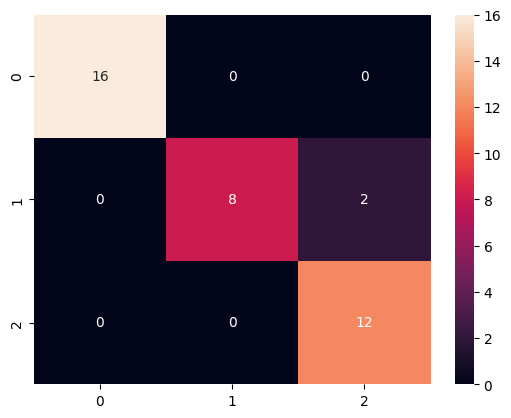

In [81]:
sns.heatmap(matriz, annot=True)

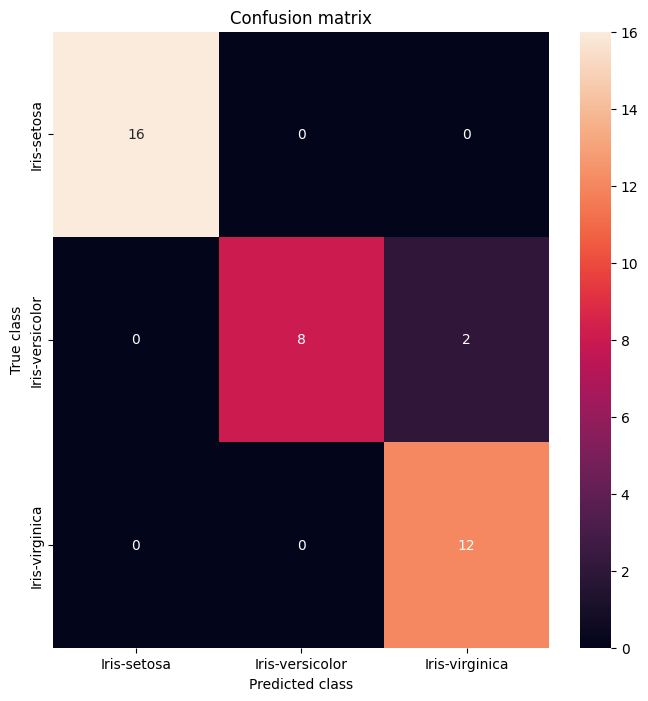

In [84]:
LABELS = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

plt.figure(figsize=(8, 8))
sns.heatmap(matriz, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()